# Schritt 1: Der Einarmige Bandit – Exploration vs. Exploitation

## Das Dilemma

Stell dir vor, du stehst vor einem Spielautomaten mit **k Hebeln (Armen)**.
Jeder Arm hat eine **unbekannte** Gewinnwahrscheinlichkeit.
Du hast ein begrenztes Budget von 1.000 Versuchen.

**Wie gehst du vor?**

- Probierst du alle Arme aus? → Du verlierst viele Versuche mit schlechten Armen.
- Bleibst du beim ersten guten Arm? → Du übersiehst vielleicht einen noch besseren.

Genau das ist das **Exploration-Exploitation-Dilemma** – eines der zentralen Probleme in Reinforcement Learning.

## Das Beispiel aus der Vorlesung

- k = 10 Arme
- Budget = 1.000 Versuche
- Jeder Gewinn = 1 Euro
- Strategie: Erste 100 Versuche zum Erkunden, restliche 900 für den besten Arm

Dieses Notebook arbeitet dieses Beispiel **Schritt für Schritt** durch.

## Leitfragen

- Wie viele Versuche sollte man zum Erkunden verwenden?
- Ist es schlimm, den falschen „besten Arm" zu identifizieren?
- Wann ist ε-Greedy besser als die einfache Explore-then-Exploit-Strategie?

# Schritt 2: Bibliotheken importieren

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# Schritt 3: Das Prinzip verstehen – Mini-Beispiel mit k=3

## Erst klein denken: 3 Arme, 12 Versuche

Bevor wir das volle Beispiel aus der Vorlesung (k=10, Budget=1000) betrachten,
verstehen wir das Prinzip an einem winzigen Beispiel.

**Szenario:** 3 Spielautomaten, 12 Versuche, Budget aufteilen:
- Phase 1 (Exploration): Jeden Arm **2×** ziehen → 6 Versuche
- Phase 2 (Exploitation): Den besten Arm **6×** ziehen → 6 Versuche

Wir schauen uns an, was dabei passiert.

In [2]:
# Mini-Bandit: 3 Arme mit bekannten (aber für den Agenten unbekannten) Wahrscheinlichkeiten
np.random.seed(7)
true_probs_mini = [0.3, 0.7, 0.5]   # Arm 2 ist der beste
arm_names = ["Arm 1", "Arm 2", "Arm 3"]

print("=== Mini-Beispiel: k=3, Budget=12 ===")
print()
print("Wahre Gewinnwahrscheinlichkeiten (der Agent kennt diese NICHT):")
for i, p in enumerate(true_probs_mini):
    best = " ← bester Arm!" if p == max(true_probs_mini) else ""
    print(f"  {arm_names[i]}: {p:.0%}{best}")

print()
print("─" * 45)
print("PHASE 1: Exploration (jeden Arm 2× ziehen)")
print("─" * 45)

counts    = [0, 0, 0]
estimates = [0.0, 0.0, 0.0]
total_reward = 0

for arm in range(3):
    for trial in range(2):
        result = 1 if np.random.rand() < true_probs_mini[arm] else 0
        counts[arm] += 1
        estimates[arm] += (result - estimates[arm]) / counts[arm]
        total_reward += result
        print(f"  Ziehe {arm_names[arm]}: Ergebnis = {result}  "
              f"→ Schätzwert = {estimates[arm]:.2f}")

print()
best_est = int(np.argmax(estimates))
print(f"Schätzwerte nach Phase 1:  {[f'{e:.2f}' for e in estimates]}")
print(f"Geschätzter bester Arm:    {arm_names[best_est]}  (Schätzwert: {estimates[best_est]:.2f})")
print(f"Wirklich bester Arm:       {arm_names[1]}  (Wahrsch.: {true_probs_mini[1]:.2f})")
print(f"Richtig erkannt:           {best_est == 1}")

print()
print("─" * 45)
print(f"PHASE 2: Exploitation ({arm_names[best_est]} 6× ziehen)")
print("─" * 45)

for trial in range(6):
    result = 1 if np.random.rand() < true_probs_mini[best_est] else 0
    total_reward += result
    print(f"  Ziehe {arm_names[best_est]}: Ergebnis = {result}")

print()
print(f"Gesamtgewinn: {total_reward} von 12 Versuchen  ({total_reward/12:.0%} Trefferquote)")
print(f"Zum Vergleich – optimale Rate (immer Arm 2): {true_probs_mini[1]:.0%}")

=== Mini-Beispiel: k=3, Budget=12 ===

Wahre Gewinnwahrscheinlichkeiten (der Agent kennt diese NICHT):
  Arm 1: 30%
  Arm 2: 70% ← bester Arm!
  Arm 3: 50%

─────────────────────────────────────────────
PHASE 1: Exploration (jeden Arm 2× ziehen)
─────────────────────────────────────────────
  Ziehe Arm 1: Ergebnis = 1  → Schätzwert = 1.00
  Ziehe Arm 1: Ergebnis = 0  → Schätzwert = 0.50
  Ziehe Arm 2: Ergebnis = 1  → Schätzwert = 1.00
  Ziehe Arm 2: Ergebnis = 0  → Schätzwert = 0.50
  Ziehe Arm 3: Ergebnis = 0  → Schätzwert = 0.00
  Ziehe Arm 3: Ergebnis = 0  → Schätzwert = 0.00

Schätzwerte nach Phase 1:  ['0.50', '0.50', '0.00']
Geschätzter bester Arm:    Arm 1  (Schätzwert: 0.50)
Wirklich bester Arm:       Arm 2  (Wahrsch.: 0.70)
Richtig erkannt:           False

─────────────────────────────────────────────
PHASE 2: Exploitation (Arm 1 6× ziehen)
─────────────────────────────────────────────
  Ziehe Arm 1: Ergebnis = 0
  Ziehe Arm 1: Ergebnis = 1
  Ziehe Arm 1: Ergebnis = 1
  Ziehe

# Schritt 4: Das Mini-Beispiel visualisieren

## Was ist in Phase 1 passiert?

Die folgende Grafik zeigt das Kernproblem der Exploration:
Mit nur 2 Versuchen pro Arm ist die Schätzung noch sehr ungenau.
Trotzdem kann der Agent oft den richtigen Arm identifizieren.

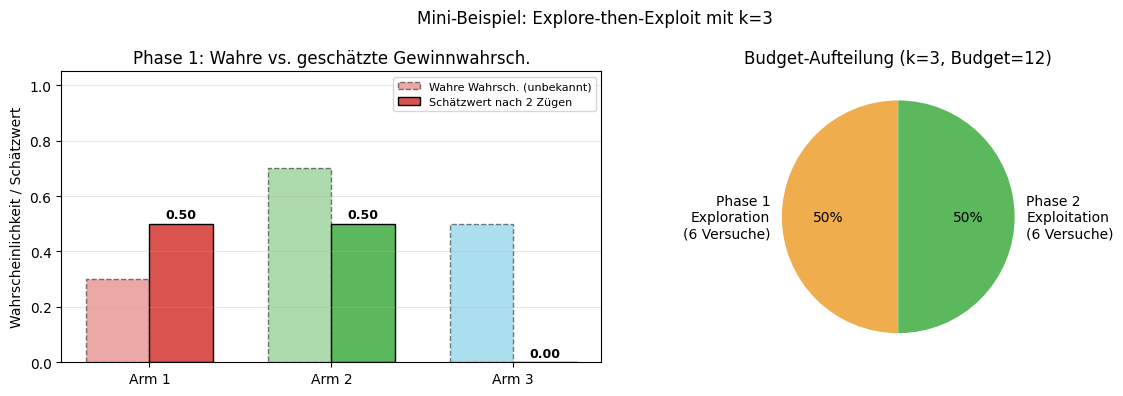

Beobachtung: Mit nur 2 Zügen pro Arm kann der Schätzwert stark vom
wahren Wert abweichen. Mit mehr Explorationsversuchen wird der Schätzwert genauer.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Links: wahre Wahrscheinlichkeiten vs. Schätzwerte
x = np.arange(3)
width = 0.35

bars1 = axes[0].bar(x - width/2, true_probs_mini, width,
                     label='Wahre Wahrsch. (unbekannt)',
                     color=['#d9534f','#5cb85c','#5bc0de'],
                     alpha=0.5, edgecolor='black', linestyle='--')
bars2 = axes[0].bar(x + width/2, estimates, width,
                     label='Schätzwert nach 2 Zügen',
                     color=['#d9534f','#5cb85c','#5bc0de'],
                     edgecolor='black')

axes[0].set_xticks(x)
axes[0].set_xticklabels(arm_names)
axes[0].set_ylabel("Wahrscheinlichkeit / Schätzwert")
axes[0].set_title("Phase 1: Wahre vs. geschätzte Gewinnwahrsch.")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars2, estimates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# Rechts: Budget-Aufteilung
labels   = ['''Phase 1
Exploration
(6 Versuche)''', '''Phase 2
Exploitation
(6 Versuche)''']
sizes    = [6, 6]
colors_p = ['#f0ad4e', '#5cb85c']
axes[1].pie(sizes, labels=labels, colors=colors_p, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title("Budget-Aufteilung (k=3, Budget=12)")

plt.suptitle("Mini-Beispiel: Explore-then-Exploit mit k=3", fontsize=12)
plt.tight_layout()
plt.show()

print("Beobachtung: Mit nur 2 Zügen pro Arm kann der Schätzwert stark vom")
print("wahren Wert abweichen. Mit mehr Explorationsversuchen wird der Schätzwert genauer.")

# Schritt 5: Das Vorlesungsbeispiel – k=10, Budget=1.000

## Jetzt das vollständige Beispiel aus den Folien

- **k = 10 Arme**
- **Budget = 1.000 Versuche**
- **Strategie**: 100 Versuche zum Erkunden, 900 für den besten Arm

Zuerst erstellen wir den Banditen und schauen uns die wahren (dem Agenten unbekannten)
Gewinnwahrscheinlichkeiten an.

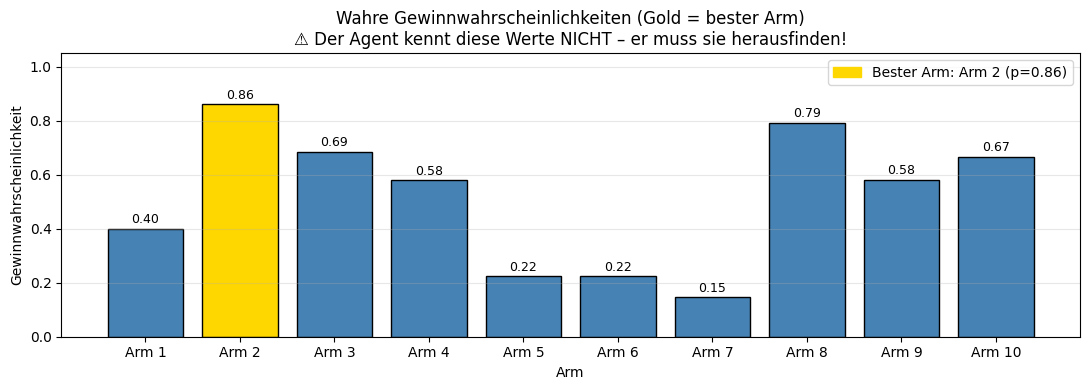

Bester Arm: Arm 2 mit Gewinnwahrsch. 0.86
(Diese Information kennt der Agent NICHT — er muss sie erst herausfinden!)


In [7]:
np.random.seed(42)

class KArmedBandit:
    # k-armiger Bandit.
    # Die wahren Gewinnwahrscheinlichkeiten sind dem Agenten NICHT bekannt.
    def __init__(self, k=10, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.k          = k
        self.true_probs = np.random.uniform(0.1, 0.9, size=k)
        self.best_arm   = int(np.argmax(self.true_probs))
        self.best_prob  = self.true_probs[self.best_arm]

    def pull(self, arm):
        return 1 if np.random.rand() < self.true_probs[arm] else 0

bandit = KArmedBandit(k=10, seed=42)

# Visualisierung der wahren Wahrscheinlichkeiten
fig, ax = plt.subplots(figsize=(11, 4))
colors = ['steelblue'] * bandit.k
colors[bandit.best_arm] = 'gold'

bars = ax.bar(range(bandit.k), bandit.true_probs,
              color=colors, edgecolor='black')
ax.set_xlabel('Arm')
ax.set_ylabel('Gewinnwahrscheinlichkeit')
ax.set_title('Wahre Gewinnwahrscheinlichkeiten (Gold = bester Arm)\n' \
             '⚠ Der Agent kennt diese Werte NICHT – er muss sie herausfinden!')
ax.set_xticks(range(bandit.k))
ax.set_xticklabels([f'Arm {i+1}' for i in range(bandit.k)])
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
for bar, p in zip(bars, bandit.true_probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{p:.2f}', ha='center', fontsize=9)

gold_patch = mpatches.Patch(color='gold', label=f'Bester Arm: Arm {bandit.best_arm+1} (p={bandit.best_prob:.2f})')
ax.legend(handles=[gold_patch])
plt.tight_layout()
plt.show()

print(f"Bester Arm: Arm {bandit.best_arm+1} mit Gewinnwahrsch. {bandit.best_prob:.2f}")
print("(Diese Information kennt der Agent NICHT — er muss sie erst herausfinden!)")

# Schritt 6: Phase 1 – Exploration (die ersten 100 Versuche)

## Jeden Arm 10× ziehen und Schätzwerte aufbauen

In Phase 1 zieht der Agent **jeden der 10 Arme genau 10×**.
Das ergibt 100 Versuche und liefert erste Schätzwerte für alle Arme.

Wir schauen uns an:
- Wie gut schätzen wir die wahren Wahrscheinlichkeiten nach 10 Zügen?
- Finden wir den richtigen besten Arm?

In [8]:
np.random.seed(42)
bandit_demo = KArmedBandit(k=10, seed=42)

k = bandit_demo.k
pulls_per_arm = 10          # 10× pro Arm = 100 Explorationsversuche
counts    = np.zeros(k)
estimates = np.zeros(k)
total_reward_phase1 = 0

print("=== PHASE 1: Exploration (100 Versuche, je 10× pro Arm) ===")
print()
print(f"{'Arm':<6} {'Züge':>5} {'Gewinner':>8} {'Schätzwert':>11} {'Wahrer Wert':>12} {'Abweichung':>11}")
print("─" * 60)

for arm in range(k):
    wins = 0
    for _ in range(pulls_per_arm):
        r = bandit_demo.pull(arm)
        counts[arm] += 1
        estimates[arm] += (r - estimates[arm]) / counts[arm]
        total_reward_phase1 += r
        if r == 1:
            wins += 1
    diff = estimates[arm] - bandit_demo.true_probs[arm]
    print(f"Arm {arm+1:<2}  {int(counts[arm]):>5}   {wins:>5}x     "
          f"{estimates[arm]:>8.2f}     {bandit_demo.true_probs[arm]:>8.2f}   "
          f"  {diff:>+.2f}")

best_arm_est = int(np.argmax(estimates))
print()
print(f"Reward in Phase 1: {total_reward_phase1} von 100 Versuchen")
print()
print(f"Geschätzter bester Arm: Arm {best_arm_est+1}  (Schätzwert: {estimates[best_arm_est]:.2f})")
print(f"Wirklich bester Arm:    Arm {bandit_demo.best_arm+1}  (Wahrsch.: {bandit_demo.best_prob:.2f})")
print(f"Richtig erkannt: {'✓  JA' if best_arm_est == bandit_demo.best_arm else '✗  NEIN – wir exploitieren den falschen Arm!'}")

=== PHASE 1: Exploration (100 Versuche, je 10× pro Arm) ===

Arm     Züge Gewinner  Schätzwert  Wahrer Wert  Abweichung
────────────────────────────────────────────────────────────
Arm 1      10       6x         0.60         0.40     +0.20
Arm 2      10      10x         1.00         0.86     +0.14
Arm 3      10       7x         0.70         0.69     +0.01
Arm 4      10       8x         0.80         0.58     +0.22
Arm 5      10       3x         0.30         0.22     +0.08
Arm 6      10       2x         0.20         0.22     -0.02
Arm 7      10       3x         0.30         0.15     +0.15
Arm 8      10       8x         0.80         0.79     +0.01
Arm 9      10       7x         0.70         0.58     +0.12
Arm 10     10       8x         0.80         0.67     +0.13

Reward in Phase 1: 62 von 100 Versuchen

Geschätzter bester Arm: Arm 2  (Schätzwert: 1.00)
Wirklich bester Arm:    Arm 2  (Wahrsch.: 0.86)
Richtig erkannt: ✓  JA


# Schritt 7: Phase 1 visualisieren – Schätzwerte vs. wahre Werte

## Wie genau ist unsere Schätzung nach 10 Zügen pro Arm?

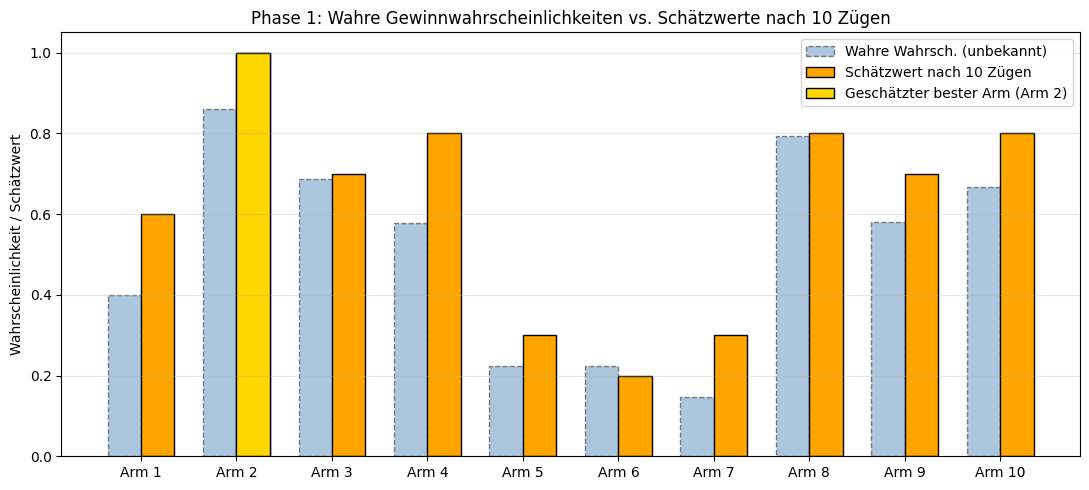

Beobachtung: Mit nur 10 Zügen pro Arm liegt der Schätzwert oft etwas daneben.
Trotzdem reicht das meist aus, um den besten Arm zu identifizieren.


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(k)
width = 0.35

bars_true = ax.bar(x - width/2, bandit_demo.true_probs, width,
                    label='Wahre Wahrsch. (unbekannt)', alpha=0.45,
                    color='steelblue', edgecolor='black', linestyle='--')
bars_est  = ax.bar(x + width/2, estimates, width,
                    label='Schätzwert nach 10 Zügen',
                    color='orange', edgecolor='black')

# Besten geschätzten Arm markieren
ax.bar(best_arm_est + width/2, estimates[best_arm_est], width,
       color='gold', edgecolor='black', label=f'Geschätzter bester Arm (Arm {best_arm_est+1})')

ax.set_xticks(x)
ax.set_xticklabels([f'Arm {i+1}' for i in range(k)])
ax.set_ylabel("Wahrscheinlichkeit / Schätzwert")
ax.set_title("Phase 1: Wahre Gewinnwahrscheinlichkeiten vs. Schätzwerte nach 10 Zügen")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Beobachtung: Mit nur 10 Zügen pro Arm liegt der Schätzwert oft etwas daneben.")
print("Trotzdem reicht das meist aus, um den besten Arm zu identifizieren.")

# Schritt 8: Phase 2 – Exploitation (die restlichen 900 Versuche)

## Den geschätzten besten Arm immer wieder ziehen

Nach Phase 1 wissen wir (mit einiger Unsicherheit), welcher Arm der beste ist.
In Phase 2 ziehen wir diesen Arm die restlichen **900 Versuche** lang.

=== PHASE 2: Exploitation (900 Versuche auf Arm 2) ===



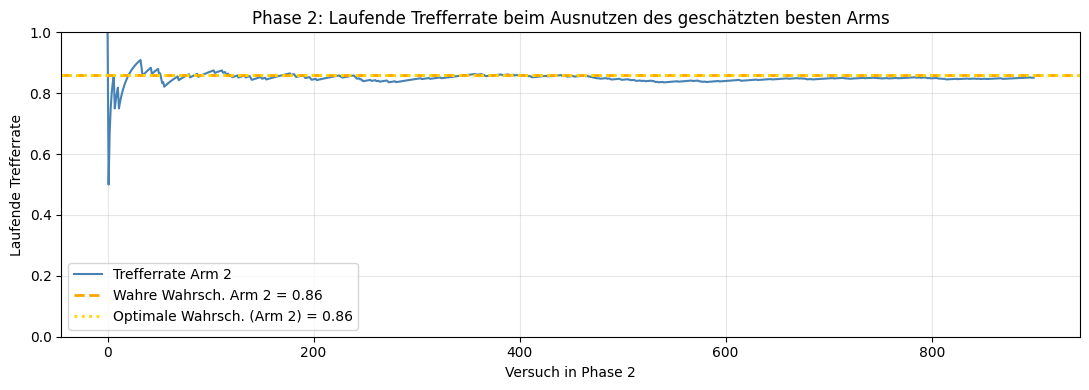

Reward Phase 1 (100 Explore):     62  von 100 Versuchen
Reward Phase 2 (900 Exploit):    766  von 900 Versuchen
──────────────────────────────────────────
Gesamtgewinn:                    828  von 1000 Versuchen
Erreichte Rate:                 82.8%

Theoretisches Optimum (immer Arm 2): ~861 von 1000
Verlust durch Exploration:       ~32 Euro


In [10]:
np.random.seed(42)

exploit_budget = 900
total_reward_phase2 = 0

print(f"=== PHASE 2: Exploitation (900 Versuche auf Arm {best_arm_est+1}) ===")
print()

rewards_phase2 = []
for t in range(exploit_budget):
    r = bandit_demo.pull(best_arm_est)
    total_reward_phase2 += r
    rewards_phase2.append(r)

# Laufende Gewinnrate
running_rate = np.cumsum(rewards_phase2) / np.arange(1, exploit_budget + 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(running_rate, color='steelblue', linewidth=1.5, label=f'Trefferrate Arm {best_arm_est+1}')
ax.axhline(y=bandit_demo.true_probs[best_arm_est], color='orange',
           linestyle='--', linewidth=2,
           label=f'Wahre Wahrsch. Arm {best_arm_est+1} = {bandit_demo.true_probs[best_arm_est]:.2f}')
ax.axhline(y=bandit_demo.best_prob, color='gold',
           linestyle=':', linewidth=2,
           label=f'Optimale Wahrsch. (Arm {bandit_demo.best_arm+1}) = {bandit_demo.best_prob:.2f}')
ax.set_xlabel('Versuch in Phase 2')
ax.set_ylabel('Laufende Trefferrate')
ax.set_title('Phase 2: Laufende Trefferrate beim Ausnutzen des geschätzten besten Arms')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

total_reward = total_reward_phase1 + total_reward_phase2
print(f"Reward Phase 1 (100 Explore):   {total_reward_phase1:>4}  von 100 Versuchen")
print(f"Reward Phase 2 (900 Exploit):   {total_reward_phase2:>4}  von 900 Versuchen")
print(f"{'─'*42}")
print(f"Gesamtgewinn:                   {total_reward:>4}  von 1000 Versuchen")
print(f"Erreichte Rate:                 {total_reward/1000:.1%}")
print()
print(f"Theoretisches Optimum (immer Arm {bandit_demo.best_arm+1}): ~{bandit_demo.best_prob*1000:.0f} von 1000")
print(f"Verlust durch Exploration:       ~{int(bandit_demo.best_prob*1000) - total_reward} Euro")

# Schritt 9: Wie viel Exploration ist optimal?

## Was passiert, wenn wir das Explorations-Budget variieren?

Zu wenig Exploration → schlechte Schätzwerte → falscher bester Arm
Zu viel Exploration → zu wenig Versuche zum Ausnutzen

Wo liegt das Optimum?

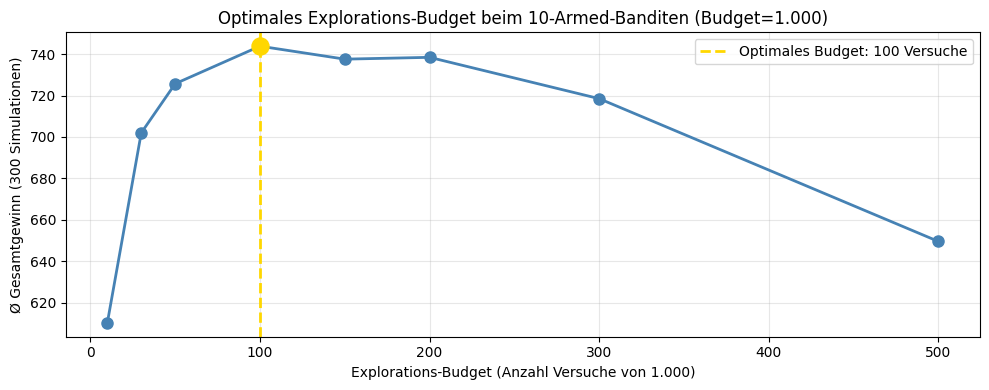

Optimales Explorations-Budget: 100 von 1.000 Versuchen
Das entspricht 10% des Gesamtbudgets

Beobachtung:
  Zu wenig Exploration → schlechte Schätzwerte → falscher Arm gewählt
  Zu viel Exploration  → zu wenige Versuche zum Ausnutzen
  Sweet Spot:          → ~100 Versuche (10%)


In [11]:
explore_budgets = [10, 30, 50, 100, 150, 200, 300, 500]
N_SIMS = 300
mean_rewards = []

for exp_budget in explore_budgets:
    run_rewards = []
    for _ in range(N_SIMS):
        b = KArmedBandit(k=10)
        pulls_per_arm = max(1, exp_budget // b.k)
        counts_s    = np.zeros(b.k)
        estimates_s = np.zeros(b.k)
        total_r = 0

        # Phase 1
        for arm in range(b.k):
            for _ in range(pulls_per_arm):
                r = b.pull(arm)
                counts_s[arm] += 1
                estimates_s[arm] += (r - estimates_s[arm]) / counts_s[arm]
                total_r += r

        # Phase 2
        best = int(np.argmax(estimates_s))
        used = b.k * pulls_per_arm
        for _ in range(1000 - used):
            total_r += b.pull(best)
        run_rewards.append(total_r)

    mean_rewards.append(np.mean(run_rewards))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(explore_budgets, mean_rewards, marker='o', color='steelblue',
        linewidth=2, markersize=8)

best_idx    = int(np.argmax(mean_rewards))
best_budget = explore_budgets[best_idx]
ax.axvline(x=best_budget, color='gold', linestyle='--', linewidth=2,
           label=f'Optimales Budget: {best_budget} Versuche')
ax.scatter([best_budget], [mean_rewards[best_idx]],
           color='gold', s=150, zorder=5)

ax.set_xlabel('Explorations-Budget (Anzahl Versuche von 1.000)')
ax.set_ylabel(f'Ø Gesamtgewinn ({N_SIMS} Simulationen)')
ax.set_title('Optimales Explorations-Budget beim 10-Armed-Banditen (Budget=1.000)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimales Explorations-Budget: {best_budget} von 1.000 Versuchen")
print(f"Das entspricht {best_budget/10:.0f}% des Gesamtbudgets")
print()
print("Beobachtung:")
print("  Zu wenig Exploration → schlechte Schätzwerte → falscher Arm gewählt")
print("  Zu viel Exploration  → zu wenige Versuche zum Ausnutzen")
print(f"  Sweet Spot:          → ~{best_budget} Versuche ({best_budget/10:.0f}%)")

# Schritt 10: ε-Greedy – eine flexiblere Alternative

## Problem der Folienstrategie

Die Explore-then-Exploit-Strategie hat einen Schwachpunkt:
**Nach Phase 1 wird nie wieder exploriert.**

Was passiert, wenn wir zu Beginn Pech hatten und den falschen Arm gewählt haben?
Dann exploitieren wir 900 Versuche lang einen suboptimalen Arm.

## ε-Greedy als Lösung

ε-Greedy exploriert **dauerhaft**:
- Mit Wahrscheinlichkeit **ε** → zufälliger Arm (Exploration)
- Mit Wahrscheinlichkeit **1−ε** → bisher bester Arm (Exploitation)

Das bedeutet: Auch wenn wir anfangs den falschen Arm wählen, können wir uns noch korrigieren.

In [12]:
def epsilon_greedy(bandit, n_steps=1000, epsilon=0.1):
    k         = bandit.k
    counts    = np.zeros(k)
    estimates = np.zeros(k)
    rewards   = []

    for _ in range(n_steps):
        if np.random.rand() < epsilon:
            arm = np.random.randint(k)    # Exploration
        else:
            arm = int(np.argmax(estimates))  # Exploitation
        r = bandit.pull(arm)
        counts[arm] += 1
        estimates[arm] += (r - estimates[arm]) / counts[arm]
        rewards.append(r)

    return rewards

def folienstrategie(bandit, budget=1000, explore_budget=100):
    k             = bandit.k
    pulls_per_arm = explore_budget // k
    counts    = np.zeros(k)
    estimates = np.zeros(k)
    rewards   = []

    # Phase 1
    for arm in range(k):
        for _ in range(pulls_per_arm):
            r = bandit.pull(arm)
            counts[arm] += 1
            estimates[arm] += (r - estimates[arm]) / counts[arm]
            rewards.append(r)

    # Phase 2
    best = int(np.argmax(estimates))
    for _ in range(budget - explore_budget):
        rewards.append(bandit.pull(best))

    return rewards

print("Strategien definiert:")
print("  1. Folienstrategie  (100 Explore, 900 Exploit)")
print("  2. ε-Greedy ε=0.1   (dauerhaft 10% Exploration)")
print("  3. ε-Greedy ε=0.01  (dauerhaft 1% Exploration)")

Strategien definiert:
  1. Folienstrategie  (100 Explore, 900 Exploit)
  2. ε-Greedy ε=0.1   (dauerhaft 10% Exploration)
  3. ε-Greedy ε=0.01  (dauerhaft 1% Exploration)


# Schritt 11: Vergleich – Folienstrategie vs. ε-Greedy

## Welche Strategie ist besser?

Wir simulieren 200 Durchläufe mit jeweils einem neuen Banditen
und vergleichen die kumulativen Rewards.

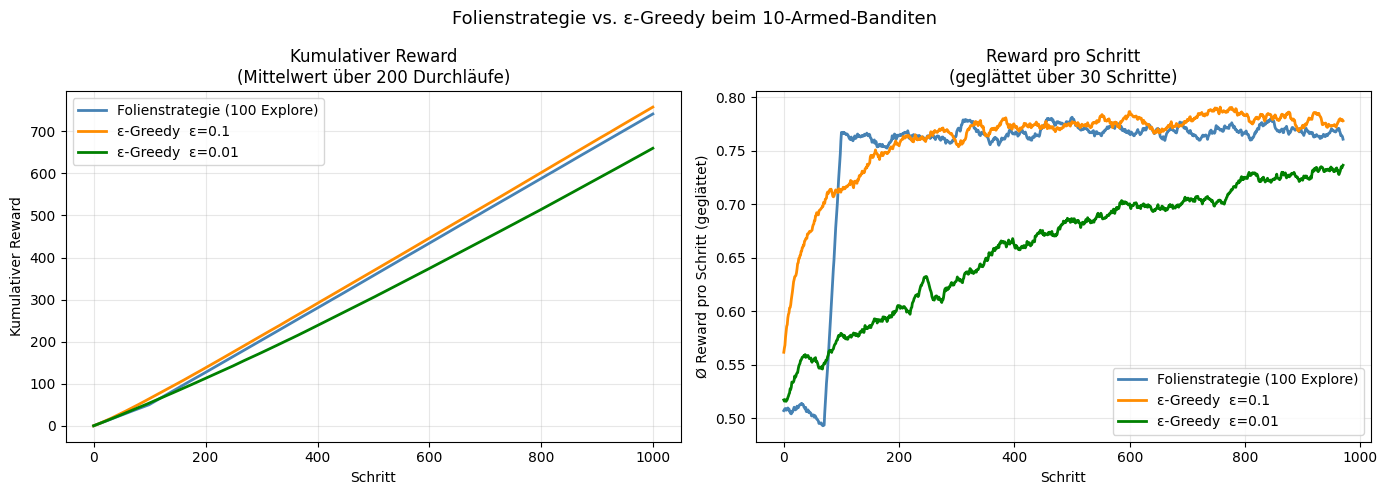

Gesamtreward nach 1.000 Schritten (Ø über alle Runs):

  Folienstrategie (100 Explore)      :  740.8
  ε-Greedy  ε=0.1                    :  757.2
  ε-Greedy  ε=0.01                   :  659.4

Beobachtung:
  ε-Greedy (ε=0.1) und die Folienstrategie liegen oft ähnlich.
  ε-Greedy hat den Vorteil: Falls Phase 1 einen falschen Arm wählt,
  kann sich das Modell durch fortlaufende Exploration noch korrigieren.


In [15]:
N_RUNS   = 200
N_STEPS  = 1000

strategies = [
    ("Folienstrategie (100 Explore)",  lambda b: folienstrategie(b, 1000, 100)),
    ("ε-Greedy  ε=0.1",               lambda b: epsilon_greedy(b, 1000, 0.1)),
    ("ε-Greedy  ε=0.01",              lambda b: epsilon_greedy(b, 1000, 0.01)),
]
colors_s = ["steelblue", "darkorange", "green"]

all_rewards = {name: np.zeros(N_STEPS) for name, _ in strategies}

for _ in range(N_RUNS):
    b = KArmedBandit(k=10)
    for name, fn in strategies:
        rews = fn(b)
        all_rewards[name] += np.array(rews)

for name in all_rewards:
    all_rewards[name] /= N_RUNS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Kumulativer Reward
for (name, _), col in zip(strategies, colors_s):
    ax1.plot(np.cumsum(all_rewards[name]), label=name, color=col, linewidth=2)
ax1.set_xlabel("Schritt")
ax1.set_ylabel("Kumulativer Reward")
ax1.set_title(f"Kumulativer Reward\n(Mittelwert über {N_RUNS} Durchläufe)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gleitender Durchschnitt
for (name, _), col in zip(strategies, colors_s):
    smoothed = np.convolve(all_rewards[name], np.ones(30)/30, mode='valid')
    ax2.plot(smoothed, label=name, color=col, linewidth=2)
ax2.set_xlabel("Schritt")
ax2.set_ylabel("Ø Reward pro Schritt (geglättet)")
ax2.set_title("Reward pro Schritt\n(geglättet über 30 Schritte)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Folienstrategie vs. ε-Greedy beim 10-Armed-Banditen", fontsize=13)
plt.tight_layout()
plt.show()

print("Gesamtreward nach 1.000 Schritten (Ø über alle Runs):")
print()
for name, rews in all_rewards.items():
    print(f"  {name:<35}: {np.sum(rews):>6.1f}")
print()
print("Beobachtung:")
print("  ε-Greedy (ε=0.1) und die Folienstrategie liegen oft ähnlich.")
print("  ε-Greedy hat den Vorteil: Falls Phase 1 einen falschen Arm wählt,")
print("  kann sich das Modell durch fortlaufende Exploration noch korrigieren.")

# Schritt 12: Aufgabe

## Aufgabe: Instabiler Bandit

Bisher haben wir angenommen, dass die Gewinnwahrscheinlichkeiten konstant bleiben.

Was passiert, wenn sich die Wahrscheinlichkeiten **alle 200 Schritte zufällig ändern**?

**Ergänzen Sie die fehlenden Teile im Code:**

```python
class NonStationaryBandit:
    def __init__(self, k=10, change_every=200):
        self.k            = k
        self.change_every = change_every
        self.step_count   = 0
        self.true_probs   = np.random.uniform(0.1, 0.9, size=k)

    def pull(self, arm):
        self.step_count += 1
        if self.step_count % self.change_every == 0:
            # TODO: Wahrscheinlichkeiten neu würfeln
            pass
        # TODO: Bernoulli-Ergebnis zurückgeben
        pass
```

**Fragen:**
1. Welche Strategie (ε=0.01, ε=0.1 oder ε=0.3) funktioniert beim instabilen Banditen am besten?
2. Warum ist beim instabilen Banditen mehr Exploration wichtiger?

# Schritt 13: Musterlösung *(nur Dozenten-Version)*

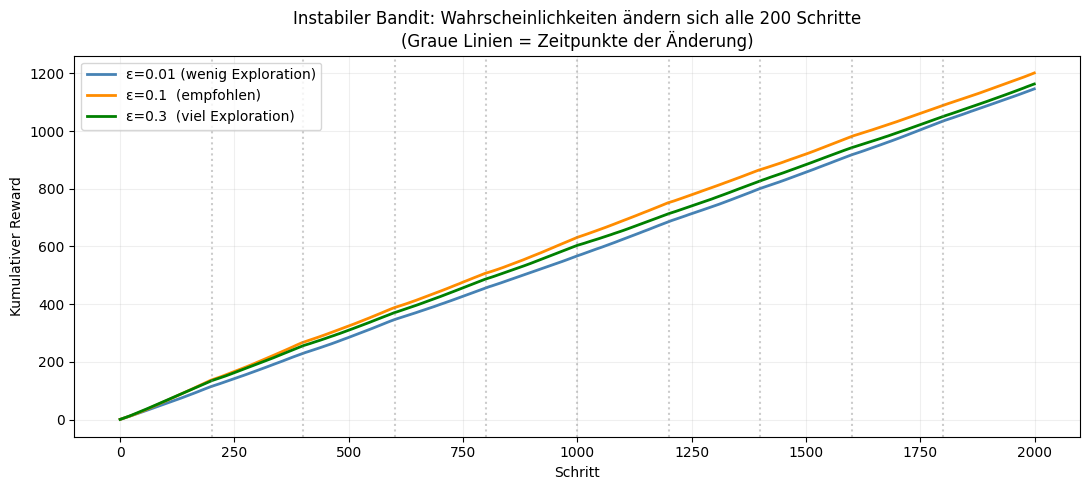

Erkenntnis: Beim instabilen Banditen ist ε=0.1 oder höher besser,
weil der Agent sich ständig an neue Wahrscheinlichkeiten anpassen muss.
ε=0.01 reagiert zu langsam auf Änderungen.


In [17]:
class NonStationaryBandit:
    """Bandit mit sich ändernden Gewinnwahrscheinlichkeiten."""
    def __init__(self, k=10, change_every=200):
        self.k            = k
        self.change_every = change_every
        self.step_count   = 0
        self.true_probs   = np.random.uniform(0.1, 0.9, size=k)

    def pull(self, arm):
        self.step_count += 1
        if self.step_count % self.change_every == 0:
            self.true_probs = np.random.uniform(0.1, 0.9, size=self.k)  # Neu würfeln
        return 1 if np.random.rand() < self.true_probs[arm] else 0

N_STEPS_NS = 2000
N_RUNS_NS  = 100
epsilons   = [("ε=0.01 (wenig Exploration)", 0.01, "steelblue"),
              ("ε=0.1  (empfohlen)",         0.10, "darkorange"),
              ("ε=0.3  (viel Exploration)",  0.30, "green")]

fig, ax = plt.subplots(figsize=(11, 5))

for label, eps, col in epsilons:
    cum_rewards = np.zeros(N_STEPS_NS)
    for _ in range(N_RUNS_NS):
        b         = NonStationaryBandit(k=10, change_every=200)
        counts_ns = np.zeros(b.k)
        ests_ns   = np.zeros(b.k)
        for step in range(N_STEPS_NS):
            arm = np.random.randint(b.k) if np.random.rand() < eps else int(np.argmax(ests_ns))
            r   = b.pull(arm)
            counts_ns[arm] += 1
            ests_ns[arm]   += (r - ests_ns[arm]) / counts_ns[arm]
            cum_rewards[step] += r
    ax.plot(np.cumsum(cum_rewards / N_RUNS_NS), label=label, color=col, linewidth=2)

for change in range(200, N_STEPS_NS, 200):
    ax.axvline(x=change, color='gray', linestyle=':', alpha=0.4)

ax.set_xlabel("Schritt")
ax.set_ylabel("Kumulativer Reward")
ax.set_title("Instabiler Bandit: Wahrscheinlichkeiten ändern sich alle 200 Schritte\n" +
             "(Graue Linien = Zeitpunkte der Änderung)")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Erkenntnis: Beim instabilen Banditen ist ε=0.1 oder höher besser,")
print("weil der Agent sich ständig an neue Wahrscheinlichkeiten anpassen muss.")
print("ε=0.01 reagiert zu langsam auf Änderungen.")

# Schritt 14: Merksatz

## Merksatz

**Das Exploration-Exploitation-Dilemma gibt es in jeder Entscheidungssituation
unter Unsicherheit – von der Restaurantwahl bis zur KI-Strategie.**

| Konzept | Kernaussage |
|---------|-------------|
| **Explore-then-Exploit** | Einfach und effektiv: erst erkunden, dann ausnutzen |
| **ε-Greedy** | Flexibler: dauerhaft ein kleiner Anteil Exploration |
| **Optimales Budget** | Hängt vom Problem ab – ca. 5–15% ist oft ein guter Startpunkt |
| **Instabile Umgebung** | Mehr Exploration nötig, weil sich die Welt ändert |